# Bayesian Model Formulation

We constructed a static Bayesian latent variable model to estimate the unmetered solar generation.

Because we have standardized our continuous features (Z-scores), we can use mathematically stable, weakly-informative priors centered around 0. However, we also inject structural physics into the model to guide the sampler:
* **Temperature Squared (`beta_temp_sq`)**: We use a `HalfNormal` prior. The thermodynamics of grid demand dictate a U-shape (heating in winter, cooling in summer). Therefore, extreme temperatures must strictly *increase* demand.
* **Weekend Effect (`beta_weekend`)**: We use a Normal prior centered at a negative value, as the absence of industrial activity definitively lowers demand.
* **Solar Efficiency (`mu`)**: We use a `HalfNormal` prior. Behind-the-meter solar generation physically *must* reduce the apparent demand measured by the grid operator. It cannot mathematically increase it.

In [13]:
pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns

print(f"NumPy version: {np.__version__}")
print("PyMC imported successfully!")

NumPy version: 1.26.4
PyMC imported successfully!


In [3]:
import pytensor

# Disable C++ compilation to stop macOS warning spam. 
pytensor.config.cxx = ""

import warnings
warnings.filterwarnings("ignore")

## Load and Standardize the Data

In [4]:
# 1. Load the fully merged and engineered dataset
df = pd.read_csv('../data/merged/merged_dataset.csv')
df['date'] = pd.to_datetime(df['date'])

# Generate 3 pairs of Fourier harmonics for annual seasonality
for k in range(1, 4):
    df[f'sin_k{k}'] = np.sin(2 * np.pi * k * df['day_of_year'] / 365.25)
    df[f'cos_k{k}'] = np.cos(2 * np.pi * k * df['day_of_year'] / 365.25)

# Store standardizations for back-calculation later
demand_mean, demand_std = df['demand_mwh_day'].mean(), df['demand_mwh_day'].std()

# Standardize features (Z-scores)
df['demand_scaled'] = (df['demand_mwh_day'] - demand_mean) / demand_std
df['temp_scaled'] = (df['temp_mean_c'] - df['temp_mean_c'].mean()) / df['temp_mean_c'].std()
df['proxy_scaled'] = (df['selfcons_theoretical_mwh'] - df['selfcons_theoretical_mwh'].mean()) / df['selfcons_theoretical_mwh'].std()


## Constructing the Prior


### Define the Pymc Model

In [5]:
with pm.Model() as solar_model:
    
    # --- 1. BASELINE PRIORS ---
    # Intercept (Since data is scaled, it should be near 0)
    alpha = pm.Normal('alpha', mu=0, sigma=0.5)
    
    # Temperature (Linear and Non-Linear)
    beta_temp = pm.Normal('beta_temp', mu=0, sigma=1)
    beta_temp_sq = pm.HalfNormal('beta_temp_sq', sigma=1) # Strictly positive for the U-shape
    
    # Weekend Effect
    beta_weekend = pm.Normal('beta_weekend', mu=-1, sigma=0.5) # Informed prior: weekends drop demand
    
    # Seasonality (Fourier coefficients)
    gamma = pm.Normal('gamma', mu=0, sigma=1, shape=3)
    delta = pm.Normal('delta', mu=0, sigma=1, shape=3)
    
    # --- 2. THE LATENT STATE PRIOR ---
    # Efficiency coefficient: How much of the proxy actually reduces grid demand?
    mu_solar = pm.HalfNormal('mu_solar', sigma=0.5) # Strictly positive, because it SUBTRACTS from baseline
    
    # --- 3. ERROR & LIKELIHOOD PRIORS ---
    # Student-T parameters to handle grid anomalies (like blackouts)
    sigma_err = pm.HalfNormal('sigma_err', sigma=1)
    nu = pm.Exponential('nu', 1/29) # Degrees of freedom for heavy tails
    
    print("Priors successfully initialized inside the PyMC model context.")

Priors successfully initialized inside the PyMC model context.


### Prior Predictive Check
Are our initial assumptions physically reasonable?

In [6]:
with solar_model:
    # Construct the mathematical equations using the prior variables
    # 1. Fourier sum
    sin_matrix = df[['sin_k1', 'sin_k2', 'sin_k3']].values
    cos_matrix = df[['cos_k1', 'cos_k2', 'cos_k3']].values
    fourier_seasonality = pm.math.sum(gamma * sin_matrix + delta * cos_matrix, axis=1)
    
    # 2. Baseline Demand Equation
    baseline = (alpha + 
                beta_temp * df['temp_scaled'].values + 
                beta_temp_sq * (df['temp_scaled'].values**2) + 
                beta_weekend * df['is_weekend'].values + 
                fourier_seasonality)
    
    # 3. Final Apparent Demand (Baseline minus the Hidden Solar)
    expected_demand = baseline - (mu_solar * df['proxy_scaled'].values)
    
    # Define the likelihood (We pass observed=None to tell PyMC we are just simulating)
    obs = pm.StudentT('obs', nu=nu, mu=expected_demand, sigma=sigma_err, shape=len(df))
    
    # Sample from the prior distribution
    print("Sampling from Prior distributions...")
    prior_checks = pm.sample_prior_predictive(samples=500, random_seed=42)

Sampling from Prior distributions...


Sampling: [alpha, beta_temp, beta_temp_sq, beta_weekend, delta, gamma, mu_solar, nu, obs, sigma_err]


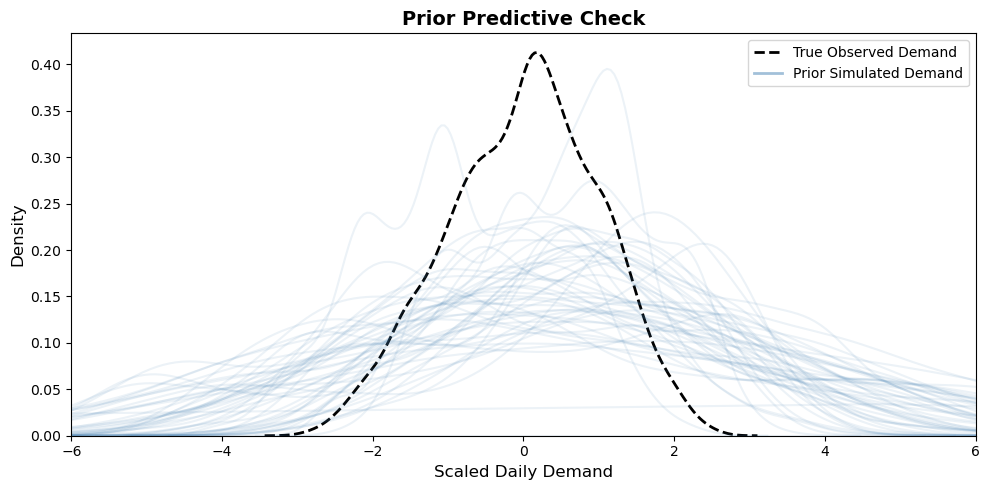

In [7]:
# 3. Visualize the Result
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(df['demand_scaled'], color='black', linewidth=2, linestyle='--', label='True Observed Demand (Scaled)', ax=ax)

# Loop through 50 random samples from our prior distribution
for i in range(50):
    # FIXED: Accessing the 'prior' group instead of 'prior_predictive'
    sns.kdeplot(prior_checks.prior['obs'][0, i].values, color='steelblue', alpha=0.1, ax=ax)

ax.set_title("Prior Predictive Check", fontsize=14, fontweight='bold')
ax.set_xlabel("Scaled Daily Demand", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_xlim(-6, 6)

from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='black', linestyle='--', lw=2),
                Line2D([0], [0], color='steelblue', lw=2, alpha=0.5)]
ax.legend(custom_lines, ['True Observed Demand', 'Prior Simulated Demand'])

plt.tight_layout()
plt.show()

### Regulate the Parameters
Initial Prior Predictive Checks using weakly-informative priors ($N(0,1)$) resulted in simulated demand distributions that were overly diffuse compared to the true observed density. To enforce thermodynamic and grid stability constraints, we tightened the prior variances (e.g., reducing sigma_err to 0.3). The subsequent Prior Predictive Check demonstrated a much closer structural alignment with reality, ensuring the MCMC sampler would not waste computational resources exploring physically impossible parameter spaces.

Sampling: [alpha, beta_temp, beta_temp_sq, beta_weekend, delta, gamma, mu_solar, nu, obs, sigma_err]


Priors successfully initialized inside the PyMC model context.
Sampling from Prior distributions...


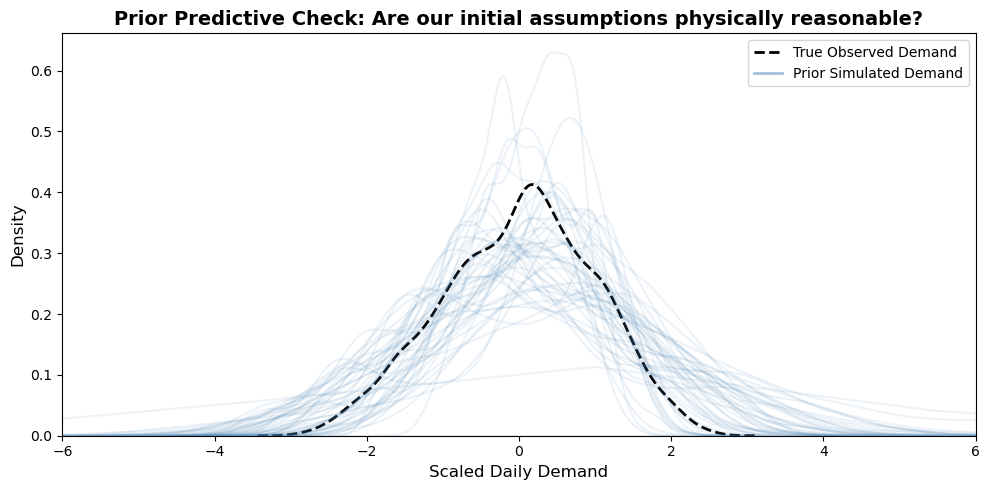

In [8]:
# Modified Prior Model
with pm.Model() as solar_model:
    
    # --- 1. BASELINE PRIORS ---
    # Intercept
    alpha = pm.Normal('alpha', mu=0, sigma=0.1)    
    # Temperature (Linear and Non-Linear)
    beta_temp = pm.Normal('beta_temp', mu=0, sigma=0.5) 
    beta_temp_sq = pm.HalfNormal('beta_temp_sq', sigma=0.5)
    
    # Weekend Effect
    # Informed prior - weekends drop demand
    beta_weekend = pm.Normal('beta_weekend', mu=-1, sigma=0.3)
    
    # Seasonality (Fourier coefficients)
    gamma = pm.Normal('gamma', mu=0, sigma=0.5, shape=3)
    delta = pm.Normal('delta', mu=0, sigma=0.5, shape=3)
    
    # --- 2. THE LATENT STATE PRIOR ---
    # Efficiency coefficient: How much of the proxy actually reduces grid demand?
    mu_solar = pm.HalfNormal('mu_solar', sigma=0.5)
    
    # --- 3. ERROR & LIKELIHOOD PRIORS ---
    # Student-T parameters to handle grid anomalies (like blackouts)
    sigma_err = pm.HalfNormal('sigma_err', sigma=0.3)
    nu = pm.Exponential('nu', 1/29) # Degrees of freedom for heavy tails
    
    print("Priors successfully initialized inside the PyMC model context.")


with solar_model:
    # Construct the mathematical equations using the prior variables
    # 1. Fourier sum
    sin_matrix = df[['sin_k1', 'sin_k2', 'sin_k3']].values
    cos_matrix = df[['cos_k1', 'cos_k2', 'cos_k3']].values
    fourier_seasonality = pm.math.sum(gamma * sin_matrix + delta * cos_matrix, axis=1)
    
    # 2. Baseline Demand Equation
    baseline = (alpha + 
                beta_temp * df['temp_scaled'].values + 
                beta_temp_sq * (df['temp_scaled'].values**2) + 
                beta_weekend * df['is_weekend'].values + 
                fourier_seasonality)
    
    # 3. Final Apparent Demand (Baseline minus the Hidden Solar)
    expected_demand = baseline - (mu_solar * df['proxy_scaled'].values)
    
    # Define the likelihood (We pass observed=None to tell PyMC we are just simulating)
    obs = pm.StudentT('obs', nu=nu, mu=expected_demand, sigma=sigma_err, shape=len(df))
    
    # Sample from the prior distribution
    print("Sampling from Prior distributions...")
    prior_checks = pm.sample_prior_predictive(samples=500, random_seed=42)

# 3. Visualize the Result
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(df['demand_scaled'], color='black', linewidth=2, linestyle='--', label='True Observed Demand (Scaled)', ax=ax)

# Loop through 50 random samples from our prior distribution
for i in range(50):
    # FIXED: Accessing the 'prior' group instead of 'prior_predictive'
    sns.kdeplot(prior_checks.prior['obs'][0, i].values, color='steelblue', alpha=0.1, ax=ax)

ax.set_title("Prior Predictive Check: Are our initial assumptions physically reasonable?", fontsize=14, fontweight='bold')
ax.set_xlabel("Scaled Daily Demand", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_xlim(-6, 6)

from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='black', linestyle='--', lw=2),
                Line2D([0], [0], color='steelblue', lw=2, alpha=0.5)]
ax.legend(custom_lines, ['True Observed Demand', 'Prior Simulated Demand'])

plt.tight_layout()
plt.show()

## Constructing the Likelihood and the Posterior

### The Likelihood Function and MCMC Sampling

With our priors validated, we now construct the final model by introducing our observed data (the actual national grid demand). 

We link our `expected_demand` to the true `demand_scaled` using a **Student-T distribution** for our likelihood function. Unlike a standard Normal distribution, the Student-T distribution has "heavy tails." This makes our model robust to extreme, unpredictable grid anomalies (such as sudden macroeconomic shocks, strikes, or the April 2025 Apagón itself) without letting those outliers skew our solar efficiency estimate ($\mu$).

Finally, we use Markov Chain Monte Carlo (MCMC) sampling to explore the parameter space. The sampler will balance our physical priors against the raw data to find the most probable hidden solar capacity.

In [9]:
with pm.Model() as final_solar_model:
    
    # 1. TIGHTENED PRIORS (from our Prior Predictive Check)
    alpha = pm.Normal('alpha', mu=0, sigma=0.1)
    beta_temp = pm.Normal('beta_temp', mu=0, sigma=0.5)
    beta_temp_sq = pm.HalfNormal('beta_temp_sq', sigma=0.5) 
    beta_weekend = pm.Normal('beta_weekend', mu=-1, sigma=0.3)
    
    gamma = pm.Normal('gamma', mu=0, sigma=0.5, shape=3)
    delta = pm.Normal('delta', mu=0, sigma=0.5, shape=3)
    
    mu_solar = pm.HalfNormal('mu_solar', sigma=0.5)
    
    # 2. BASELINE MATH
    sin_matrix = df[['sin_k1', 'sin_k2', 'sin_k3']].values
    cos_matrix = df[['cos_k1', 'cos_k2', 'cos_k3']].values
    fourier_seasonality = pm.math.sum(gamma * sin_matrix + delta * cos_matrix, axis=1)
    
    baseline = (alpha + 
                beta_temp * df['temp_scaled'].values + 
                beta_temp_sq * (df['temp_scaled'].values**2) + 
                beta_weekend * df['is_weekend'].values + 
                fourier_seasonality)
    
    expected_demand = baseline - (mu_solar * df['proxy_scaled'].values)
    
    # 3. THE LIKELIHOOD (Connecting model to observed data)
    sigma_err = pm.HalfNormal('sigma_err', sigma=0.3)
    nu = pm.Exponential('nu', 1/29) 
    
    # Notice we now pass `observed=df['demand_scaled'].values`
    obs = pm.StudentT('obs', 
                      nu=nu, 
                      mu=expected_demand, 
                      sigma=sigma_err, 
                      observed=df['demand_scaled'].values)
    
    # 4. RUN THE MCMC SAMPLER
    print("Initializing MCMC Sampler. Crunching 11 years of grid data...")
    print("Initializing NumPyro Sampler. This should be MUCH faster...")
    trace = pm.sample(draws=1000, 
                      tune=1000, 
                      chains=4, 
                      target_accept=0.95, 
                      nuts_sampler="numpyro", # <-- THE MAGIC SPEEDUP LINE
                      return_inferencedata=True,
                      random_seed=42)
    
    print("Sampling completely successfully!")

Initializing MCMC Sampler. Crunching 11 years of grid data...
Initializing NumPyro Sampler. This should be MUCH faster...


Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/2000 [00:01<?, ?it/s]


Running chain 0:   5%|▌         | 100/2000 [00:02<00:05, 364.13it/s]




Running chain 0:  10%|█         | 200/2000 [00:02<00:06, 264.92it/s]


Running chain 0:  15%|█▌        | 300/2000 [00:02<00:05, 299.98it/s]


Running chain 0:  20%|██        | 400/2000 [00:03<00:05, 317.49it/s]


Running chain 0:  25%|██▌       | 500/2000 [00:03<00:04, 313.86it/s]


Running chain 0:  30%|███       | 600/2000 [00:03<00:04, 321.18it/s]



Running chain 0:  35%|███▌      | 700/2000 [00:04<00:03, 333.40it/s]


Running chain 0:  40%|████      | 800/2000 [00:04<00:03, 334.39it/s]


Running chain 0:  45%|████▌     | 900/2000 [00:04<00:03, 326.16it/s]


Running chain 0:  50%|█████     | 1000/2000 [00:05<00:03, 292.77it/s]


Running chain 0:  55%|█████▌    | 1100/2000 [00:05<00:03, 295.53it/s]


Running chain 0:  60%|██████    | 1200/2000 [00:05<00:02, 287.40it/s]




Running chain 0:  65

Sampling completely successfully!


### Convergence Diagnostics
Before we can trust our model's estimate of the unmetered solar generation, we must mathematically prove that the MCMC chains successfully converged on the true posterior distribution. 

We do this by checking the **R-hat ($\hat{R}$)** statistic. An $\hat{R}$ value of exactly $1.00$ (or below $1.01$) across all variables proves that our 4 separate Markov chains arrived at the exact same posterior conclusions, regardless of where they started their random walks. We also visually inspect the trace plots to ensure the chains mixed well (appearing as dense, overlapping "fuzzy caterpillars").

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_solar,0.207,0.007,0.194,0.221,0.000,0.0,4042.0,2897.0,1.0
beta_temp,-0.083,0.021,-0.123,-0.044,0.001,0.0,1590.0,2140.0,1.0
beta_temp_sq,0.364,0.011,0.344,0.385,0.000,0.0,1928.0,2171.0,1.0
beta_weekend,-1.415,0.017,-1.446,-1.383,0.000,0.0,3537.0,3077.0,1.0


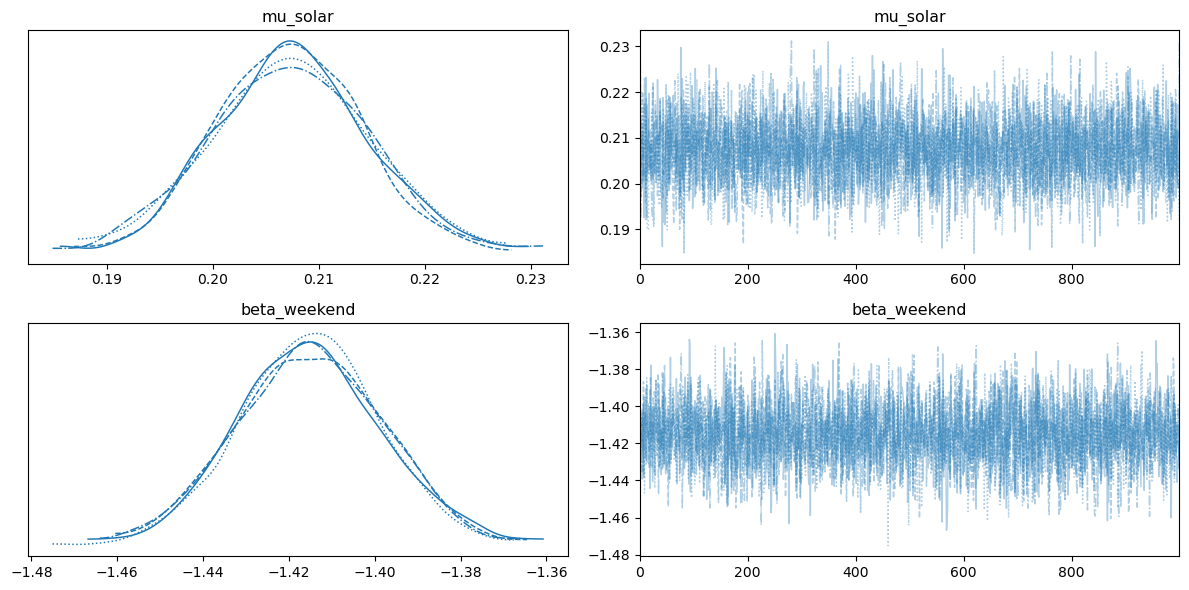

In [10]:
# Print the summary statistics (Look closely at the r_hat column!)
summary_df = az.summary(trace, var_names=['mu_solar', 'beta_temp', 'beta_temp_sq', 'beta_weekend'])
display(summary_df)

# Plot the Trace to visually confirm the chains mixed well
az.plot_trace(trace, var_names=['mu_solar', 'beta_weekend'], figsize=(12, 6))
plt.tight_layout()
plt.show()

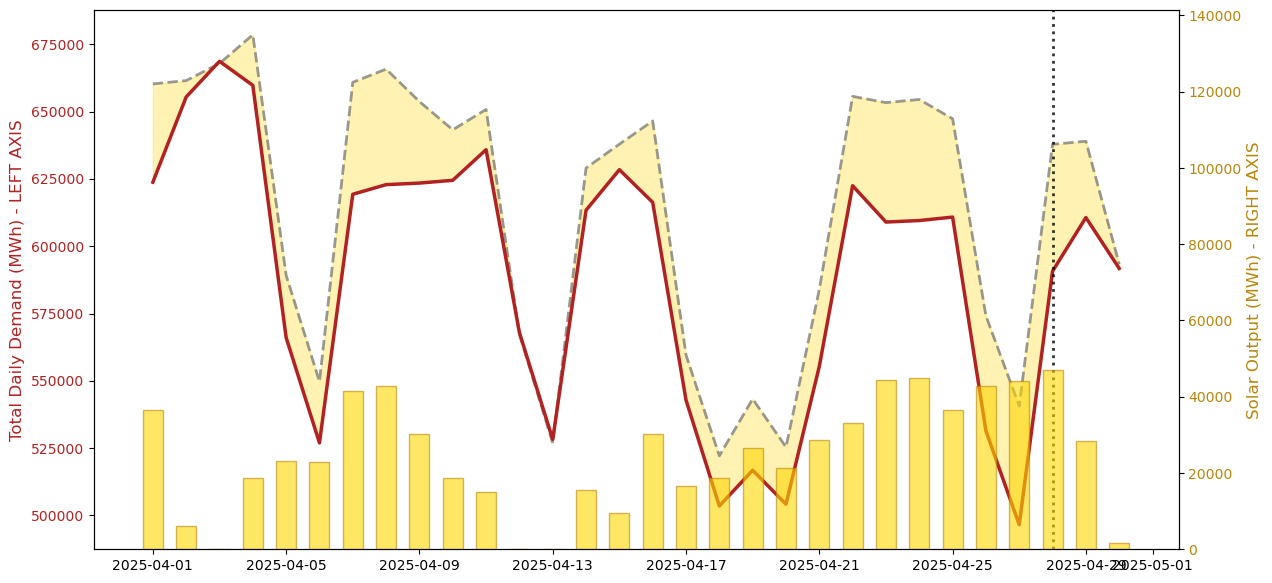

In [11]:
# 1. Grab the exact mean value the Bayesian model found for solar efficiency
mu_solar_mean = summary_df.loc['mu_solar', 'mean']

# 2. Un-scale the data to find the TRUE missing Megawatt-hours
# Since both demand and proxy were standardized, the real MWh effect is:
# (mu * proxy_scaled) * demand_std
df['hidden_solar_mwh'] = (mu_solar_mean * df['proxy_scaled']) * demand_std

# 3. Reconstruct the Baseline (What the grid WOULD have been without solar panels)
df['baseline_mwh_inferred'] = df['demand_mwh_day'] + df['hidden_solar_mwh']
# Filter the data to look specifically at the month of the Blackout (April 2025)
blackout_period = df[(df['date'] >= '2025-04-01') & (df['date'] <= '2025-04-30')].copy()

fig, ax1 = plt.subplots(figsize=(14, 7))

# ---------------------------------------------------------
# AXIS 1 (LEFT): The Macro Grid View
# ---------------------------------------------------------
ax1.plot(blackout_period['date'], blackout_period['baseline_mwh_inferred'], 
         label='Inferred Baseline Demand (True Consumption)', 
         linestyle='--', color='gray', alpha=0.8, linewidth=2)

ax1.plot(blackout_period['date'], blackout_period['demand_mwh_day'], 
         label='Apparent Grid Demand (Operator Visibility)', 
         color='firebrick', linewidth=2.5)

# Fill the gap to show the unmetered solar
ax1.fill_between(blackout_period['date'], 
                 blackout_period['demand_mwh_day'], 
                 blackout_period['baseline_mwh_inferred'], 
                 color='gold', alpha=0.3)

ax1.set_ylabel('Total Daily Demand (MWh) - LEFT AXIS', fontsize=12, color='firebrick')
ax1.tick_params(axis='y', labelcolor='firebrick')

# ---------------------------------------------------------
# AXIS 2 (RIGHT): The Isolated Hidden Solar
# ---------------------------------------------------------
ax2 = ax1.twinx() # Create a second y-axis sharing the same x-axis

ax2.bar(blackout_period['date'], blackout_period['hidden_solar_mwh'], 
        color='gold', edgecolor='darkgoldenrod', alpha=0.6, 
        label='Hidden Solar Generation (Right Axis)', width=0.6)

ax2.set_ylabel('Solar Output (MWh) - RIGHT AXIS', fontsize=12, color='darkgoldenrod')
ax2.tick_params(axis='y', labelcolor='darkgoldenrod')

# VISUAL TRICK: Force the bars to stay at the bottom of the chart
ax2.set_ylim(0, blackout_period['hidden_solar_mwh'].max() * 3) 

# ---------------------------------------------------------
# HIGHLIGHTING THE BLACKOUT (April 28, 2025)
# ---------------------------------------------------------
apagon_date = pd.to_datetime('2025-04-28')

# Draw a vertical dotted line straight through the chart
ax1.axvline(apagon_date, color='black', linestyle=':', linewidth=2, alpha=0.8)

# Add a text annotation pointing to the Apagón